In [1]:
#LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

### Environment Setup (Colab only)

The dataset is loaded below using the **relative repo path** `01-ml-project/retail_transactions_segmentation.csv`, as required by the submission criteria (no personal Desktop/Drive paths). This only works if the notebook's working directory is the **root of the class repo**.

- If you cloned the repo and are running this notebook from inside it (e.g. locally with Jupyter, or the mentor's grading setup), the cell below does nothing and the path just works.
- If you're running in **Google Colab** (a fresh runtime with no files), the cell below clones the repo once and switches into it, so the exact same relative path resolves correctly.

In [2]:
import os

REPO_URL = 'https://github.com/HozaifaMoustafa/arabian-ai-training.git'
REPO_DIR = 'arabian-ai-training'

if not os.path.exists('01-ml-project'):
    if not os.path.exists(REPO_DIR):
        get_ipython().system('git clone -q {} {}'.format(REPO_URL, REPO_DIR))
    os.chdir(REPO_DIR)

print('Current working directory:', os.getcwd())
print('Dataset found at expected relative path:', os.path.exists('01-ml-project/retail_transactions_segmentation.csv'))

Current working directory: /content/arabian-ai-training
Dataset found at expected relative path: True


## Point 1 — RFM Feature Table Built From Raw Transactions

The raw data is at the transaction level, not the customer level. This section builds a customer-level RFM table:
- **Recency**: days since the customer's last purchase, measured from a fixed reference date.
- **Frequency**: number of transactions per customer.
- **Monetary**: total amount spent per customer.

**Reference date used:** the day after the last transaction date in the dataset (`max(transaction_date) + 1 day`), so the minimum Recency is 1 instead of 0.
**Monetary choice:** total spend (`sum`), to reflect each customer's cumulative value.

In [3]:
df = pd.read_csv('01-ml-project/retail_transactions_segmentation.csv')
print(f'Shape of dataset: {df.shape}')
print('\nData Types & Non-Null Counts')
df.info()
df.head()
print('\nMissing Values:')
print(df.isnull().sum())
print(f'\nNumber of duplicated records: {df.duplicated().sum()}')
df['transaction_date'] = pd.to_datetime(
    df['transaction_date'],
    errors='coerce'
)
print(
    f'\nTransaction Date Range: '
    f'{df["transaction_date"].min()} to '
    f'{df["transaction_date"].max()}'
)
reference_date = df['transaction_date'].max() + pd.Timedelta(days=1)
print(f'\nReference Date: {reference_date}')
rfm = df.groupby('customer_id').agg(
    Recency=(
        'transaction_date',
        lambda x: (reference_date - x.max()).days
    ),
    Frequency=(
        'transaction_date',
        'count'
    ),
    Monetary=(
        'amount',
        'sum'
    )
).reset_index()
print('\nRFM Table:')
print(rfm.head())
print(f'\nRFM Table Shape: {rfm.shape}')
print('\nRFM Data Types & Non-Null Counts')
rfm.info()
print('\nMissing Values in RFM Table:')
print(rfm.isnull().sum())
print(
    f'\nNumber of Unique Customers in Dataset: '
    f'{df["customer_id"].nunique()}'
)

print(
    f'Number of Customers in RFM Table: '
    f'{rfm["customer_id"].nunique()}'
)
print('\nRFM Descriptive Statistics:')
print(
    rfm[['Recency', 'Frequency', 'Monetary']].describe()
)

Shape of dataset: (3663, 4)

Data Types & Non-Null Counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3663 entries, 0 to 3662
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       3663 non-null   int64  
 1   transaction_date  3663 non-null   object 
 2   amount            3663 non-null   float64
 3   product_category  3663 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 114.6+ KB

Missing Values:
customer_id         0
transaction_date    0
amount              0
product_category    0
dtype: int64

Number of duplicated records: 0

Transaction Date Range: 2024-01-01 00:00:00 to 2024-12-30 00:00:00

Reference Date: 2024-12-31 00:00:00

RFM Table:
   customer_id  Recency  Frequency  Monetary
0         5001        2         16   5172.45
1         5002       23         18   6158.98
2         5003       37          3    654.12
3         5004        5         35  31050.

**Data checks:** customer counts match before and after grouping (300 unique customers), the RFM table has no missing values, and all values are logical (no negatives).

### Outlier Handling on Monetary

The `describe()` table above shows Monetary is right-skewed (mean 6264 EGP vs. max 39424 EGP), driven by a small group of very high-spending customers. These are not data errors — they are a real "big spender" segment — so we don't remove or cap them. Instead, we create a log-transformed version, `Monetary_log = log1p(Monetary)`, and **use this version (instead of raw Monetary) in the scaling and clustering steps below**. This reduces the influence extreme spenders have on the K-Means distance calculations, without discarding any customer. The original `Monetary` column is kept unchanged and is still used later for the persona table, so the reported amounts stay in real EGP.

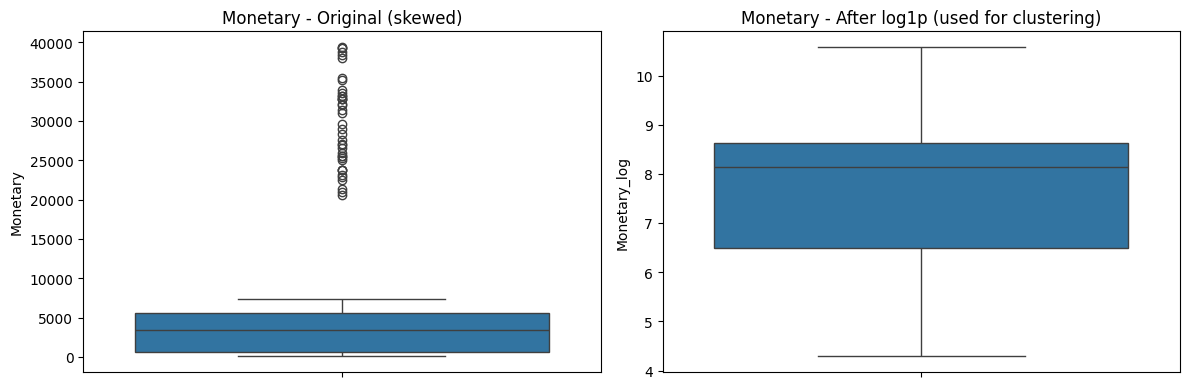

Monetary skewness before log: 2.16
Monetary skewness after log: 0.01


In [4]:
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=rfm['Monetary'], ax=axes[0])
axes[0].set_title('Monetary - Original (skewed)')
sns.boxplot(y=rfm['Monetary_log'], ax=axes[1])
axes[1].set_title('Monetary - After log1p (used for clustering)')
plt.tight_layout()
plt.savefig('__fig_outlier.png', dpi=110, bbox_inches='tight')
plt.show()

print("Monetary skewness before log:", rfm['Monetary'].skew().round(2))
print("Monetary skewness after log:", rfm['Monetary_log'].skew().round(2))

## Point 2 — Features Scaled Before Clustering

Recency, Frequency and Monetary_log are on different scales (days, order counts, and a log-money value). Without scaling, one feature could dominate the distance calculations in K-Means simply because its numbers are bigger. `StandardScaler` puts all three features on the same scale before clustering. Note: we scale `Monetary_log` (not raw `Monetary`) as decided in the Outlier Handling step above, so the extreme spenders don't disproportionately pull the clusters.

In [5]:
rfm_features = rfm[['Recency', 'Frequency', 'Monetary_log']]
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary_log'])
rfm_scaled_df.head()

,Recency,Frequency,Monetary_log
0,-0.772792,0.356692,0.549008
1,-0.464634,0.544920,0.664967
2,-0.259195,-0.866790,-0.823936
3,-0.728770,2.144859,1.739673
4,-0.420611,0.356692,0.613628


## Point 3 — Choice of k Justified With Evidence

We test k from 2 to 10 and compute, for each value:
- **Inertia** (for the Elbow Method).
- **Silhouette Score** (how tight and well-separated the clusters are).

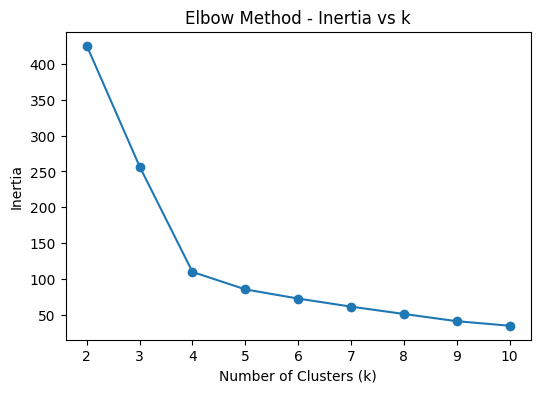

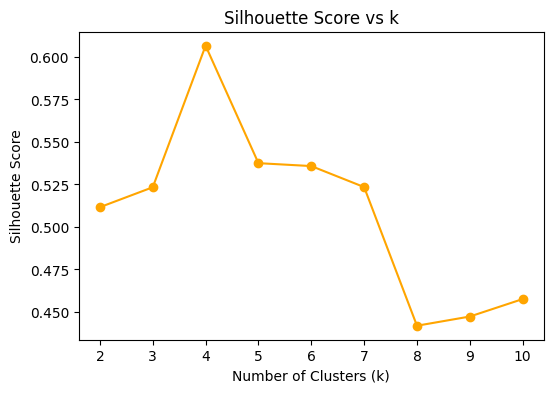

Inertia values: [425.271290071405, 256.80952819378194, 109.86445657672616, 85.52835804191747, 72.71794002121077, 61.48438793554177, 51.272233515516255, 41.194241310965495, 34.86646690824104]
Silhouette values: [np.float64(0.5116136645787984), np.float64(0.523333696724421), np.float64(0.6065792054860504), np.float64(0.5374993312809799), np.float64(0.5357918463320281), np.float64(0.5234356012767656), np.float64(0.44188308292737966), np.float64(0.4472863509018808), np.float64(0.4575564703681308)]


In [6]:
inertia_values = []
silhouette_values = []
k_range = range(2, 11)
for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  labels = kmeans.fit_predict(rfm_scaled)
  inertia_values.append(kmeans.inertia_)
  silhouette_values.append(silhouette_score(rfm_scaled, labels))
  # Elbow plot
plt.figure(figsize=(6, 4))
plt.plot(list(k_range), inertia_values, marker='o')
plt.title('Elbow Method - Inertia vs k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.savefig('__fig_elbow.png', dpi=110, bbox_inches='tight')
plt.show()
# Silhouette plot
plt.figure(figsize=(6, 4))
plt.plot(list(k_range), silhouette_values, marker='o', color='orange')
plt.title('Silhouette Score vs k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.savefig('__fig_silhouette.png', dpi=110, bbox_inches='tight')
plt.show()
print(f'Inertia values: {inertia_values}')
print(f'Silhouette values: {silhouette_values}')

**Reading the plots and choosing k:**
In the Elbow plot, inertia drops sharply up to around k=4, then the rate of decrease slows down noticeably — this is the "elbow" point.

In the Silhouette plot (computed on Recency, Frequency and the log-transformed Monetary), the scores across k=2 to 10 are: k=2: 0.512, k=3: 0.523, k=4: 0.607, k=5: 0.537, k=6: 0.536, k=7: 0.523, k=8: 0.442, k=9: 0.447, k=10: 0.458. The score reaches its **maximum at k=4 (0.607)**, higher than its immediate neighbors (k=3: 0.523, k=5: 0.537), and clearly higher than smaller k values (k=2: 0.512, k=3: 0.523).

**Final decision: k = 4.**
We chose 4 clusters because it is the point where the Silhouette Score peaks — the clusters are the tightest and best separated at this value. This also matches the elbow in the Inertia plot, where the drop clearly slows down around the same k. A smaller k (2 or 3) would merge genuinely different customer segments together (e.g. VIP and Loyal), while a larger k would split customers into clusters too small to be useful for business decisions. k=4 is also easy to interpret: each cluster ends up with clear, distinct RFM characteristics, which lets us build clean personas with practical marketing recommendations.

## Point 4 — K-Means Fitted With Chosen k

K-Means is fitted on the scaled features (Recency, Frequency, Monetary_log) using the k justified above, with `random_state` fixed for reproducibility. The resulting cluster label is attached back to each customer in the RFM table. Cluster centers are also converted back to real units — including back-transforming Monetary_log to approximate EGP with `expm1` — purely for interpretation.

In [7]:
k_optimal = 4
print(f"\n[1] Applying K-Means with k={k_optimal}")

kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("\n[2] Cluster Distribution:")
print(rfm['Cluster'].value_counts().sort_index())

cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': ['mean', 'min', 'max'],
    'Frequency': ['mean', 'min', 'max'],
    'Monetary': ['mean', 'min', 'max', 'count']
}).round(2)

print("\n[3] Cluster Summary - RFM Statistics (Monetary in real EGP):")
print(cluster_summary)

cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
cluster_centers_df = pd.DataFrame(
    cluster_centers,
    columns=['Recency', 'Frequency', 'Monetary_log']
)
cluster_centers_df['Monetary (approx EGP)'] = np.expm1(cluster_centers_df['Monetary_log'])

print("\n[4] Cluster Centers - Original Scale:")
print(cluster_centers_df.round(2))


[1] Applying K-Means with k=4

[2] Cluster Distribution:
Cluster
0     40
1    116
2    123
3     21
Name: count, dtype: int64

[3] Cluster Summary - RFM Statistics (Monetary in real EGP):
        Recency           Frequency          Monetary                      \
           mean  min  max      mean min max      mean       min       max   
Cluster                                                                     
0          8.40    2   15     35.00  25  45  29683.61  20531.31  39424.12   
1         68.80    1  158      4.31   1   8    764.62     71.92   1683.11   
2         20.74    1   40     13.98   8  20   4849.21   1567.04   7414.80   
3        263.38  171  337      2.10   1   4    320.48     83.62    661.42   

               
        count  
Cluster        
0          40  
1         116  
2         123  
3          21  

[4] Cluster Centers - Original Scale:
   Recency  Frequency  Monetary_log  Monetary (approx EGP)
0     8.40      35.00         10.28               29149.09
1

## Point 5 — PCA Visualization of the Clusters

The three scaled features (Recency, Frequency, Monetary_log) are reduced to 2 principal components with PCA so all clusters can be shown in a single readable scatter plot, keeping as much of the original variance as possible.


[5] PCA Explained Variance Ratio:
PC1: 79.46%
PC2: 18.33%
Total Explained Variance: 97.79%


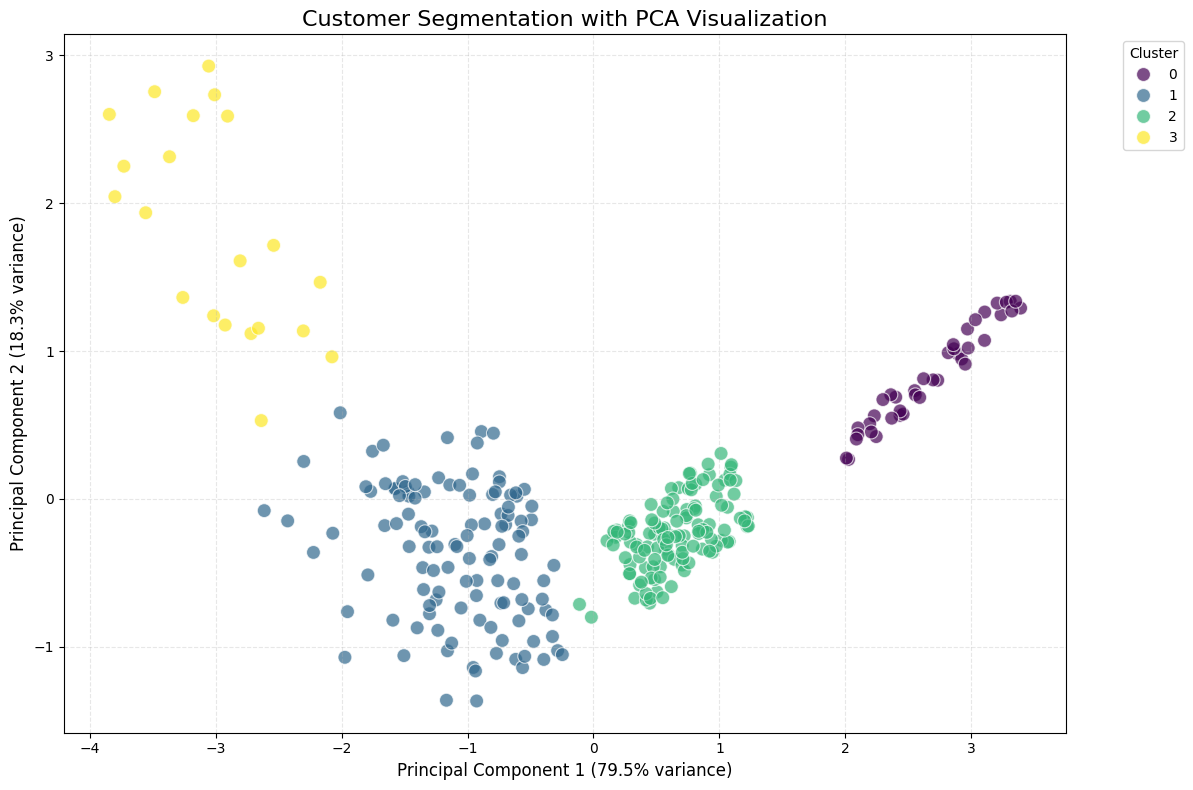

In [8]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(rfm_scaled)
rfm['PCA1'] = pca_result[:, 0]
rfm['PCA2'] = pca_result[:, 1]

print(f"\n[5] PCA Explained Variance Ratio:")
print(f"PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"Total Explained Variance: {pca.explained_variance_ratio_.sum():.2%}")

plt.figure(figsize=(12, 8))

scatter = sns.scatterplot(
    data=rfm,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='viridis',
    s=100,
    alpha=0.7
)

plt.title('Customer Segmentation with PCA Visualization', fontsize=16)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('__fig_pca.png', dpi=110, bbox_inches='tight')
plt.show()

K-Means was applied to the scaled RFM data (with log-transformed Monetary) using the k justified in Point 3. The per-cluster averages show which groups buy a lot, buy rarely, are still active, or have gone quiet. PCA is used purely for visualization, so all clusters can be seen in one 2D plot with distinct colors.

###Saving the final customer segments table for later use.

In [9]:
rfm.to_csv('customer_segments_final.csv')
print("\n[6] Final Customer Segments Saved to 'customer_segments_final.csv'")


[6] Final Customer Segments Saved to 'customer_segments_final.csv'


## Point 6 — Named Personas Grounded in the Numbers

The mean Recency, Frequency and Monetary (real EGP, from the original un-transformed column) per cluster are computed as evidence, and each cluster is given a real business name that matches its numbers.

In [10]:
persona_names = {0: 'VIP (Champions)', 2: 'Loyal Customers', 1: 'Occasional Buyers', 3: 'Lost / Hibernating'}

personas_summary = rfm.groupby('Cluster').agg(
    Recency_Mean=('Recency', 'mean'),
    Frequency_Mean=('Frequency', 'mean'),
    Monetary_Mean=('Monetary', 'mean'),
    Customer_Count=('Cluster', 'count')
).reset_index()

personas_summary['Percentage (%)'] = (personas_summary['Customer_Count'] / len(rfm)) * 100
personas_summary['Persona Name'] = personas_summary['Cluster'].map(persona_names)

final_table = personas_summary[[
    'Cluster', 'Persona Name', 'Recency_Mean',
    'Frequency_Mean', 'Monetary_Mean', 'Customer_Count', 'Percentage (%)'
]]

final_table.columns = [
    'Cluster ID', 'Persona Name', 'Recency (Days)',
    'Frequency (Orders)', 'Monetary (EGP)', 'Customer Count', 'Percentage (%)'
]

final_table.style.background_gradient(cmap='Blues', subset=['Monetary (EGP)', 'Customer Count'])\
    .format({
        'Recency (Days)': '{:.2f}',
        'Frequency (Orders)': '{:.2f}',
        'Monetary (EGP)': '{:,.2f}',
        'Percentage (%)': '{:.2f}%'
    })

,Cluster ID,Persona Name,Recency (Days),Frequency (Orders),Monetary (EGP),Customer Count,Percentage (%)
0,0,VIP (Champions),8.40,35.00,"29,683.61",40,13.33%
1,1,Occasional Buyers,68.80,4.31,764.62,116,38.67%
2,2,Loyal Customers,20.74,13.98,"4,849.21",123,41.00%
3,3,Lost / Hibernating,263.38,2.10,320.48,21,7.00%


### Customer Persona Analysis and Marketing Recommendations

**Cluster 0 — VIP (Champions):**
40 customers (13.33%). Average Recency: 8.4 days, Average Frequency: 35.0 orders, Average Monetary: 29,683.61 EGP. *Recommendation:* give them special VIP treatment, early access to new products, and exclusive offers to keep their loyalty.
**Cluster 1 — Occasional Buyers:**
116 customers (38.67%). Average Recency: 68.8 days, Average Frequency: 4.3 orders, Average Monetary: 764.62 EGP. *Recommendation:* send reminder emails and personalized product recommendations with a discount code to increase purchase frequency.
**Cluster 2 — Loyal Customers:**
123 customers (41.00%). Average Recency: 20.7 days, Average Frequency: 14.0 orders, Average Monetary: 4,849.21 EGP. *Recommendation:* use points/loyalty programs and complementary offers to help push them toward VIP status.
**Cluster 3 — Lost / Hibernating:**
21 customers (7.00%). Average Recency: 263.4 days, Average Frequency: 2.1 orders, Average Monetary: 320.48 EGP. *Recommendation:* avoid spending a large marketing budget on them; rely only on low-cost automated email campaigns to try to win them back.